# 04C — Compare the eight controlled experiments

This notebook reads **saved Stage-04 results only**. It does not generate features, train or evaluate models.
It compares two complete frozen acoustic frontend configurations. TEST metrics are descriptive, not tuning
signals. The provisional Stage-05 shortlist uses selected-validation macro-F1, then parameter count and run ID.


Portability: storage is resolved by `tools/project_paths.py`. Accepted outputs are read-only. Use `04D_experiments.ipynb` for the Colab bootstrap and non-training smoke test. Saved cell outputs below are historical.


In [2]:
# Each notebook kernel discovers its own runtime checkout.
from pathlib import Path, PureWindowsPath
import os, subprocess, sys
_repo_hint = os.environ.get("EDGEAI_REPO_ROOT")
if _repo_hint and os.name != "nt" and PureWindowsPath(_repo_hint).drive:
    raise RuntimeError("EDGEAI_REPO_ROOT must name the checkout in this runtime, not a Windows drive")
_start = Path(_repo_hint).expanduser().resolve() if _repo_hint else Path.cwd().resolve()
_candidates = [_start, *_start.parents, Path("/content/edge-ai")]
_repo = next((p for p in _candidates if (p / "tools/project_paths.py").is_file()), None)
if _repo is None:
    try:
        import google.colab
    except ImportError:
        raise RuntimeError("Set EDGEAI_REPO_ROOT to your local checkout and rerun this cell") from None
    _repo = Path(_repo_hint or "/content/edge-ai").expanduser().resolve()
    if _repo.exists():
        raise RuntimeError(f"{_repo} exists but is not an EdgeAI checkout; set EDGEAI_REPO_ROOT to the correct checkout")
    subprocess.run(["git", "clone", "https://github.com/ancaranovik/Mosquito_Wingbeat_v1.git", str(_repo)], check=True)
if not (_repo / "tools/notebook_runtime.py").is_file():
    raise RuntimeError("Checkout is missing notebook_runtime.py. Pull the latest GitHub commit in this runtime, then rerun this cell")
sys.path.insert(0, str(_repo / "tools"))
from notebook_runtime import initialize
PATHS = initialize(_repo)
from project_paths import REPO_ROOT, ProjectPaths, resolve_path, logical_relative
from pathlib import Path
import sys
sys.dont_write_bytecode = True
PROJECT = REPO_ROOT
sys.path.insert(0, str(PROJECT / "tools"))
import importlib
import stage04_data, model_zoo, training_common
for module in (stage04_data, model_zoo, training_common):
    importlib.reload(module)
import pandas as pd
from IPython.display import display
from model_zoo import FAMILIES, architecture_config, build_model
from training_common import CONFIG, run_branch, compare_saved_results, RUNS
from stage04_data import BRANCHES, CLASSES, ROOT, prepare_caches, read_json


Repository: /content/edge-ai
Data: /content/drive/MyDrive/EdgeAI
Immutable baseline: /content/drive/MyDrive/EdgeAI/fixed/baseline/stage04
Future results: /content/drive/MyDrive/EdgeAI/experiments/<experiment_id>


In [3]:
status = []
for frontend in BRANCHES:
    for family in FAMILIES:
        path = RUNS / f"{frontend}_{family}_seed42" / "result.json"
        status.append({"Frontend": frontend, "Model": family,
                       "Status": read_json(path)["status"] if path.exists() else "NOT RUN"})
status = pd.DataFrame(status)
display(status)
all_complete = status.Status.eq("COMPLETE").all()
if all_complete:
    comparison = compare_saved_results()
    display(comparison)
    summary = read_json(PATHS.BASELINE_ROOT / "comparison.json")
    print("Provisional Stage-05 shortlist (validation only):", summary["stage05_shortlist"])
else:
    raise RuntimeError("Missing completed Stage-04 results; comparison requires all 8 completed authenticated runs.")


,Frontend,Model,Status
0,03A,small_cnn,COMPLETE
1,03A,ds_cnn,COMPLETE
2,03A,tc_resnet8,COMPLETE
3,03A,cnn_lstm,COMPLETE
4,03B,small_cnn,COMPLETE
5,03B,ds_cnn,COMPLETE
6,03B,tc_resnet8,COMPLETE
7,03B,cnn_lstm,COMPLETE


,Frontend,Model,Params,Model Size (bytes),Accuracy,Macro-F1,Macro-Recall,Macro-Precision,Weighted-F1,Best epoch,Selected val loss,Selected val Macro-F1
0,03A,small_cnn,23668,103093,0.421786,0.393469,0.476336,0.496562,0.368983,2,1.098061,0.442724
1,03A,ds_cnn,6244,46709,0.575270,0.567921,0.647090,0.587493,0.584522,7,0.978955,0.521331
2,03A,tc_resnet8,65940,287605,0.367812,0.355286,0.415033,0.393726,0.393045,1,1.342140,0.406385
3,03A,cnn_lstm,13428,60341,0.578410,0.558155,0.650276,0.566728,0.580288,28,0.986835,0.548213
4,03B,small_cnn,23668,103093,0.497350,0.490161,0.607536,0.557815,0.507183,8,1.029288,0.438999
5,03B,ds_cnn,6244,46709,0.513641,0.502372,0.598533,0.539732,0.530906,7,1.011103,0.496436
6,03B,tc_resnet8,64788,282997,0.547007,0.523467,0.590745,0.536114,0.560446,7,1.026463,0.499702
7,03B,cnn_lstm,13428,60341,0.460648,0.440564,0.539817,0.495576,0.440735,6,1.042559,0.460271


Provisional Stage-05 shortlist (validation only): ['03A_cnn_lstm_seed42', '03A_ds_cnn_seed42', '03B_tc_resnet8_seed42']


## Saved training histories and confusion matrices

TRAIN accuracy/F1 are online metrics with dropout; validation uses evaluation mode. All four classes
remain in macro metrics even when predictions for a class are absent. Confusion matrices use true rows
and predicted columns. Source-level metrics are secondary and retain one observation per source name.


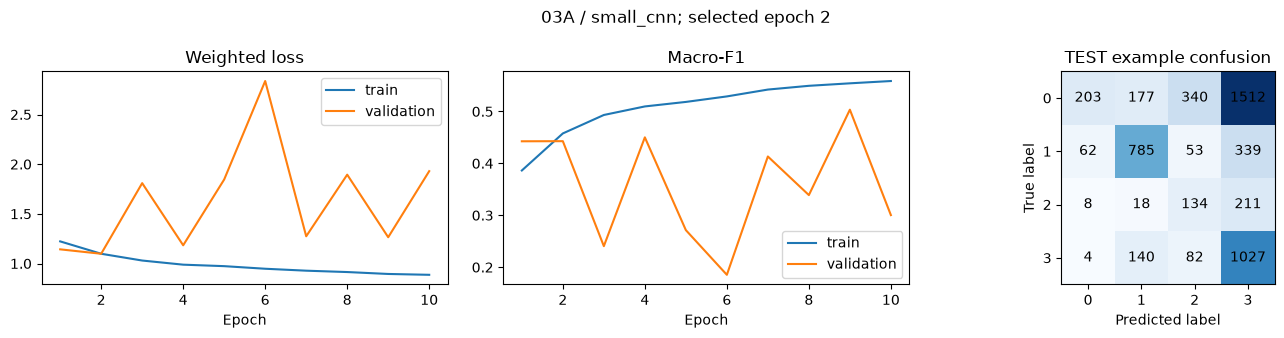

,precision,recall,f1,support
an arabiensis,0.732852,0.090950,0.161817,2232.0
an funestus ss,0.700893,0.633575,0.665536,1239.0
an squamosus,0.220033,0.361186,0.273469,371.0
culex pipiens complex,0.332470,0.819633,0.473054,1253.0


accuracy                                                     0.450549
macro_precision                                              0.556361
macro_recall                                                 0.497599
macro_f1                                                      0.42744
weighted_f1                                                  0.372682
confusion_matrix    [[4, 2, 8, 64], [1, 26, 0, 11], [1, 0, 5, 9], ...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.666666666666...
sources                                                           182
aggregation         arithmetic mean softmax over all windows shari...
Name: Secondary source evaluation, dtype: object

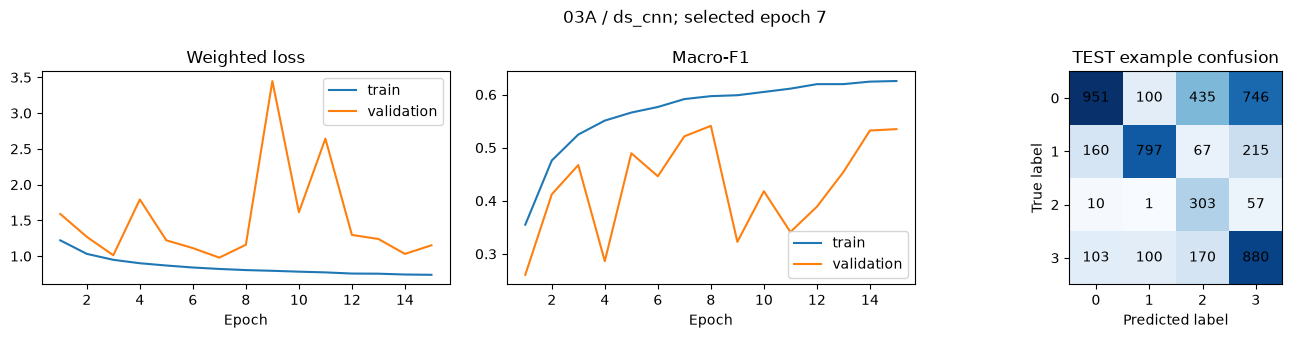

,precision,recall,f1,support
an arabiensis,0.776961,0.426075,0.550347,2232.0
an funestus ss,0.798597,0.643261,0.712561,1239.0
an squamosus,0.310769,0.816712,0.450223,371.0
culex pipiens complex,0.463646,0.702314,0.558553,1253.0


accuracy                                                     0.642857
macro_precision                                              0.685549
macro_recall                                                 0.715734
macro_f1                                                     0.651109
weighted_f1                                                  0.643509
confusion_matrix    [[34, 1, 10, 33], [2, 28, 1, 7], [0, 0, 13, 2]...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.918918918918...
sources                                                           182
aggregation         arithmetic mean softmax over all windows shari...
Name: Secondary source evaluation, dtype: object

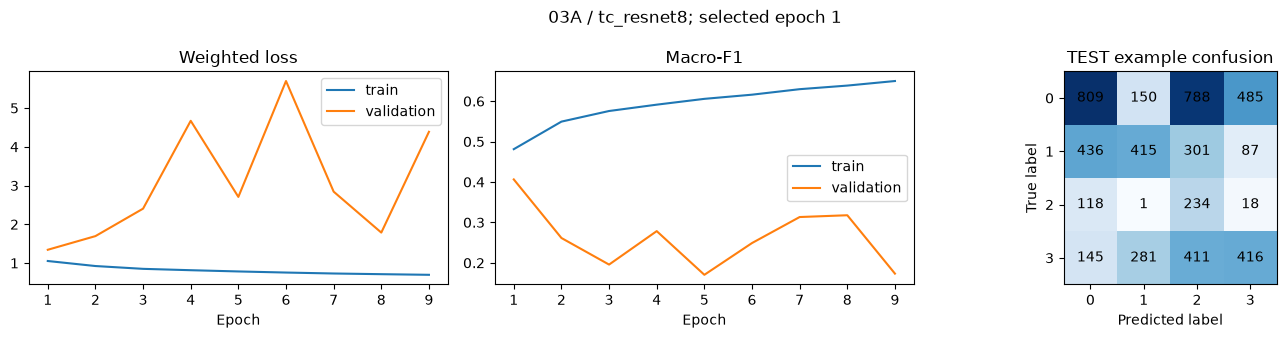

,precision,recall,f1,support
an arabiensis,0.536472,0.362455,0.432620,2232.0
an funestus ss,0.489965,0.334948,0.397891,1239.0
an squamosus,0.134948,0.630728,0.222328,371.0
culex pipiens complex,0.413519,0.332003,0.368305,1253.0


accuracy                                                     0.379121
macro_precision                                              0.396955
macro_recall                                                 0.426852
macro_f1                                                     0.372603
weighted_f1                                                  0.396881
confusion_matrix    [[25, 6, 25, 22], [13, 15, 8, 2], [6, 0, 9, 0]...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.520833333333...
sources                                                           182
aggregation         arithmetic mean softmax over all windows shari...
Name: Secondary source evaluation, dtype: object

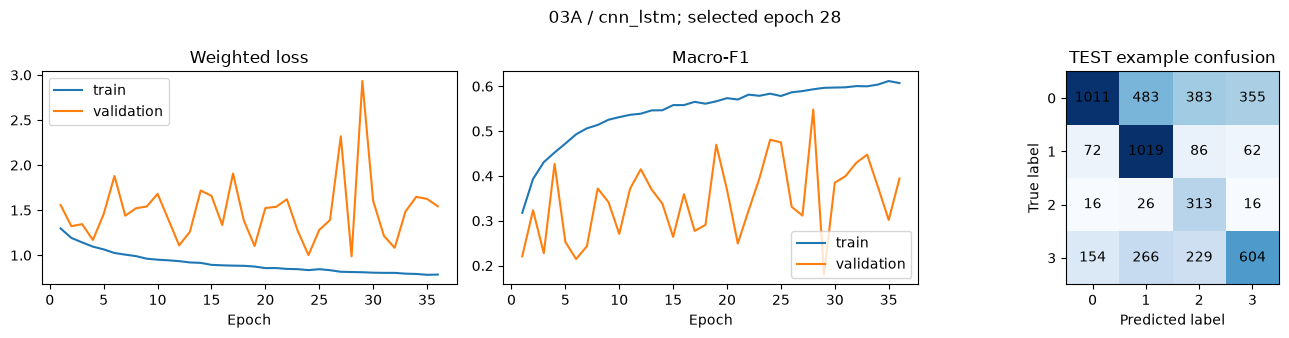

,precision,recall,f1,support
an arabiensis,0.806864,0.452957,0.580201,2232.0
an funestus ss,0.568004,0.822437,0.671942,1239.0
an squamosus,0.309594,0.843666,0.452967,371.0
culex pipiens complex,0.582449,0.482043,0.527511,1253.0


accuracy                                                     0.637363
macro_precision                                              0.634419
macro_recall                                                 0.714087
macro_f1                                                     0.620327
weighted_f1                                                  0.641818
confusion_matrix    [[39, 13, 13, 13], [0, 35, 2, 1], [1, 1, 13, 0...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.928571428571...
sources                                                           182
aggregation         arithmetic mean softmax over all windows shari...
Name: Secondary source evaluation, dtype: object

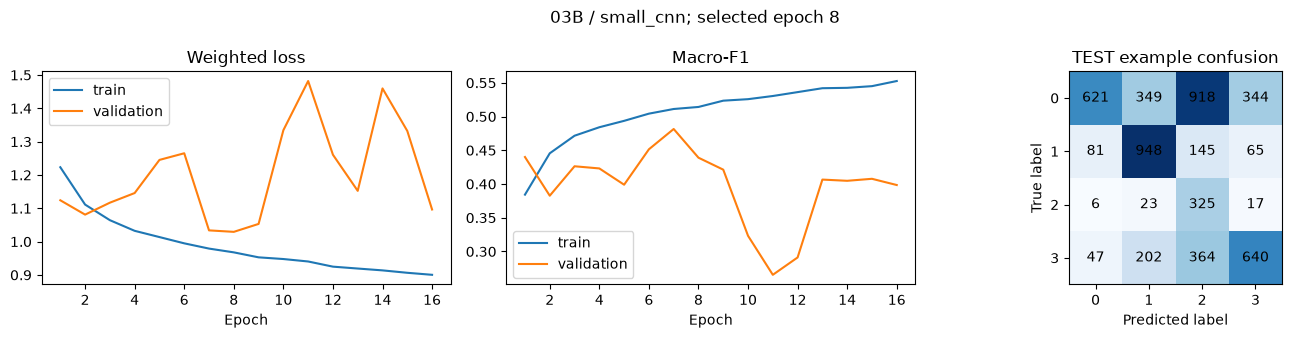

,precision,recall,f1,support
an arabiensis,0.822517,0.278226,0.415802,2232.0
an funestus ss,0.622865,0.765133,0.686708,1239.0
an squamosus,0.185502,0.876011,0.306171,371.0
culex pipiens complex,0.600375,0.510774,0.551962,1253.0


accuracy                                                     0.543956
macro_precision                                              0.646789
macro_recall                                                 0.681492
macro_f1                                                     0.550193
weighted_f1                                                  0.548961
confusion_matrix    [[20, 7, 36, 15], [0, 32, 3, 3], [0, 0, 15, 0]...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.952380952380...
sources                                                           182
aggregation         arithmetic mean softmax over all windows shari...
Name: Secondary source evaluation, dtype: object

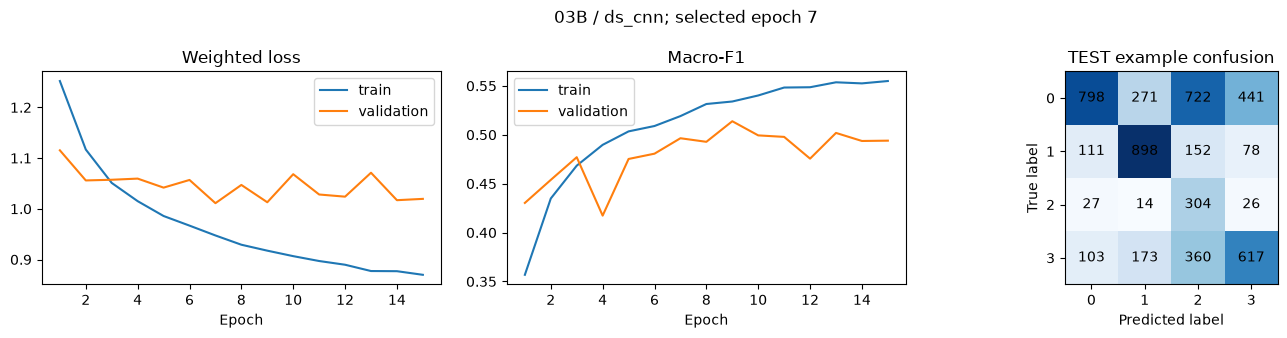

,precision,recall,f1,support
an arabiensis,0.768046,0.357527,0.487924,2232.0
an funestus ss,0.662242,0.724778,0.692100,1239.0
an squamosus,0.197659,0.819407,0.318491,371.0
culex pipiens complex,0.530981,0.492418,0.510973,1253.0


accuracy                                                     0.576923
macro_precision                                              0.624605
macro_recall                                                 0.692258
macro_f1                                                     0.583142
weighted_f1                                                  0.591376
confusion_matrix    [[30, 3, 25, 20], [2, 31, 3, 2], [0, 0, 15, 0]...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.833333333333...
sources                                                           182
aggregation         arithmetic mean softmax over all windows shari...
Name: Secondary source evaluation, dtype: object

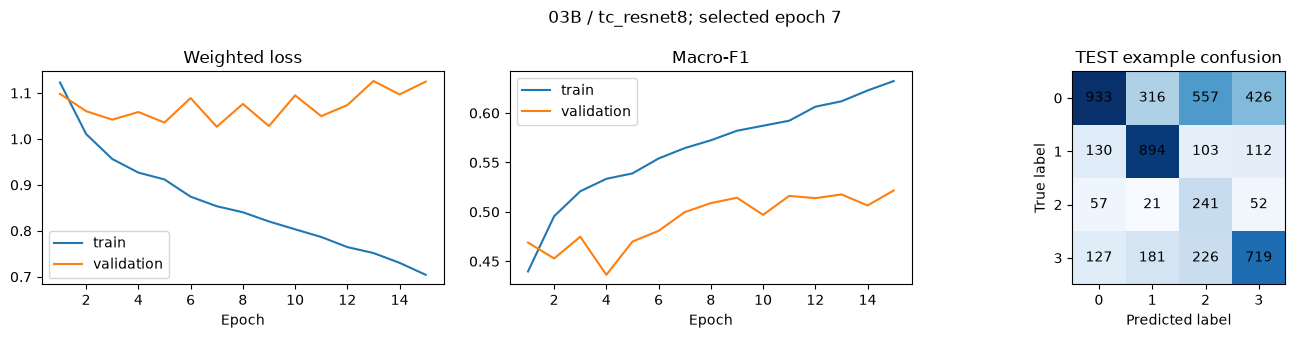

,precision,recall,f1,support
an arabiensis,0.748196,0.418011,0.536361,2232.0
an funestus ss,0.633144,0.721550,0.674462,1239.0
an squamosus,0.213842,0.649596,0.321762,371.0
culex pipiens complex,0.549274,0.573823,0.561280,1253.0


accuracy                                                     0.642857
macro_precision                                               0.63345
macro_recall                                                 0.690468
macro_f1                                                      0.62601
weighted_f1                                                  0.648973
confusion_matrix    [[37, 5, 15, 21], [2, 30, 3, 3], [3, 0, 11, 1]...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.840909090909...
sources                                                           182
aggregation         arithmetic mean softmax over all windows shari...
Name: Secondary source evaluation, dtype: object

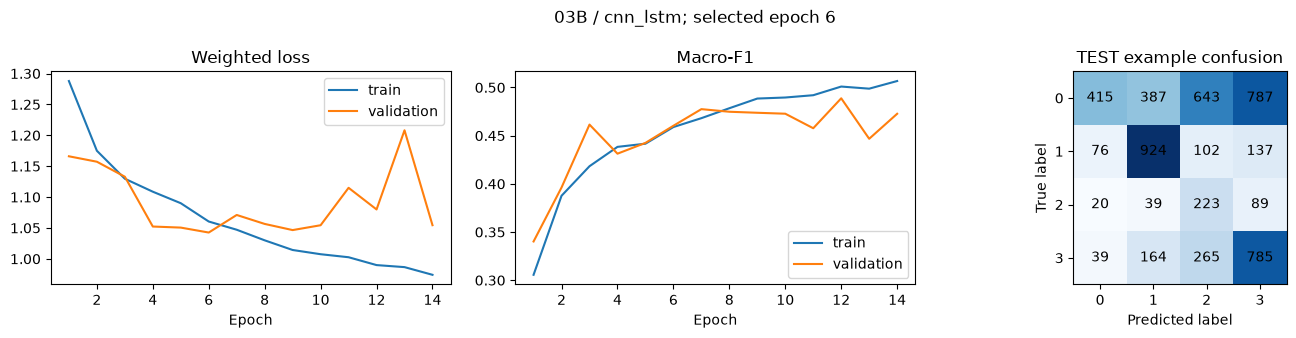

,precision,recall,f1,support
an arabiensis,0.754545,0.185932,0.298347,2232.0
an funestus ss,0.610304,0.745763,0.671268,1239.0
an squamosus,0.180860,0.601078,0.278055,371.0
culex pipiens complex,0.436596,0.626496,0.514585,1253.0


accuracy                                                     0.489011
macro_precision                                              0.567837
macro_recall                                                 0.573781
macro_f1                                                     0.468869
weighted_f1                                                  0.452609
confusion_matrix    [[12, 12, 21, 33], [0, 31, 2, 5], [1, 2, 9, 3]...
class_order         [an arabiensis, an funestus ss, an squamosus, ...
per_class           {'an arabiensis': {'precision': 0.923076923076...
sources                                                           182
aggregation         arithmetic mean softmax over all windows shari...
Name: Secondary source evaluation, dtype: object

In [4]:
if all_complete:
    import matplotlib.pyplot as plt
    for frontend in BRANCHES:
        for family in FAMILIES:
            directory = RUNS / f"{frontend}_{family}_seed42"
            result = read_json(directory / "result.json")
            history = read_json(directory / "history.json")
            fig, axes = plt.subplots(1, 3, figsize=(14, 3.4))
            epochs = [h["epoch"] for h in history]
            for split in ("train", "validation"):
                axes[0].plot(epochs, [h[split]["loss"] for h in history], label=split)
                axes[1].plot(epochs, [h[split]["macro_f1"] for h in history], label=split)
            axes[0].set(title="Weighted loss", xlabel="Epoch"); axes[0].legend()
            axes[1].set(title="Macro-F1", xlabel="Epoch"); axes[1].legend()
            cm = result["final_test_metrics"]["confusion_matrix"]
            axes[2].imshow(cm, cmap="Blues")
            for i in range(4):
                for j in range(4):
                    axes[2].text(j, i, cm[i][j], ha="center", va="center")
            axes[2].set(title="TEST example confusion", xlabel="Predicted label", ylabel="True label",
                        xticks=range(4), yticks=range(4))
            fig.suptitle(f"{frontend} / {family}; selected epoch {result['best_epoch']}")
            fig.tight_layout(); plt.show()
            display(pd.DataFrame(result["final_test_metrics"]["per_class"]).T)
            display(pd.Series(result["source_test_metrics"], name="Secondary source evaluation"))


## Limits before Stage 05

No Edge winner is declared. Float32 checkpoint size is not INT8 size, RAM, Flash or latency.
This one-seed comparison makes no claims of superiority to published literature. Multiple windows may
share one recording; source-name isolation does not prove biological/session/domain independence.
The frozen acquisition-method confounding remains. Read [Stage 04 methodology](../../docs/STAGE04.md).
